In [1]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp

# 18-2 sympy continued

## Solving equations:

Since `=` and `==` are already taken by python, an equation is declared as `Eq(lhs =  ..., rhs = ...)`

In [100]:
(x, y, z) = sp.symbols( ('x', 'y', 'z') )
eq1 = sp.Eq(lhs = x*y + x - 3 + 2*x**2 - z*x**2 + x**3, rhs = 0)
eq1

Eq(x**3 - x**2*z + 2*x**2 + x*y + x - 3, 0)

Equations can be solved using the `solveset()` function. Note that sympy can't solve any equations. It does a good job at solving linear, polynomial, and trigonometric equations.

In [101]:
sp.solveset(eq1, 'y')

{-(x**3 - x**2*z + 2*x**2 + x - 3)/x}

In [103]:
eq2 = sp.Eq(lhs = x**3 - x**2 + x - 1, rhs = 0)
sp.solveset(eq2)

{1, -I, I}

In [107]:
sp.solveset(eq2,x, domain = sp.Reals)

{1}

In [109]:
# Short version: call solveset without creating the equations
sp.solveset(x**3 - x**2 + x - 1, x, domain = sp.Reals) 

{1}

In [112]:
sp.solveset(sp.Eq(lhs = sp.sqrt(x**2), rhs = -x), domain = sp.Reals)

Interval(-oo, 0)

## Systems of linear equations
Systems of equations can be solved with `solve()`.
https://docs.sympy.org/latest/modules/solvers/solvers.html

In [115]:
solution = sp.solve((x + 5 * y - 2, -3 * x + 6 * y - 15), (x, y))
solution

{x: -3, y: 1}

In [116]:
(x,y,z) = sp.symbols( ('x', 'y', 'z') )
sp.solve([x + y - 2*z, y + 4*z],(x, y))

{x: 6*z, y: -4*z}

In [113]:
theta = sp.Symbol('theta')
sp.solveset(sp.sin(3*theta))

Union(ImageSet(Lambda(_n, 2*_n*pi/3), Integers), ImageSet(Lambda(_n, 2*_n*pi/3 + pi/3), Integers))

## Calculus with sympy

### Limits: `limit`

General syntax: `limit(e, z, z0, dir='+')`


In [3]:
x = sp.Symbol('x')
sp.limit(sp.sin(sp.pi*x)/sp.pi/x , x, 0, dir='+-')

1

#### Warning: 
The default value of `dir` is `'+'`, which may lead to some issues if the right limit exists but the limit does not. Take for instance $f(x) = \frac{x}{|x|}$. We have that $\lim_{x \to 0-} f(x) = -1$ and $\lim_{x \to 0+} f(x) = 1$ so that $\lim_{x \to 0} f(x)$ does not exist, but

In [5]:
expr = x/abs(x)
sp.limit(expr,x,0) # same as limit(expr,x,0, '+')

1

In [6]:
sp.limit(expr,x,0,'-')

-1

If we are more careful and ask for sympy to check that the left and right limits exist and are equal, we get an error:

In [7]:
sp.limit(expr,x,0,'+-')

ValueError: The limit does not exist since left hand limit = -1 and right hand limit = 1

In [8]:
sp.limit(1/x, x, 0, dir='-')

-oo

#### Limits at infinity:
sympy uses `+sp.oo` and `-sp.oo` respectively to represent $+\infty$ and $-\infty$

In [10]:
sp.limit(sp.sin(sp.pi*x)/sp.pi/x, x, -sp.oo)

0

In [11]:
a = sp.Symbol('a')
expr = 1/(x**2+a**2)
expr

1/(a**2 + x**2)

In [13]:
sp.limit(expr, x, sp.oo)

0

### Derivatives: `diff`

In [14]:
x = sp.Symbol('x')
expr = x*sp.ln(x)
expr

x*log(x)

In [15]:
derivative = sp.diff(expr, x)
# because expr depends only on x, this can be abbreviated as diff(expr)
derivative

log(x) + 1

In [16]:
# second derivative
sp.diff(sp.diff(expr,x),x)

1/x

In [17]:
# Alternative syntax:
sp.diff(expr,x,x)
# or diff(expr,x,2)

1/x

In [18]:
sp.diff(expr, x, 5)

-6/x**4

### Partial derivatives:
Explicitely specifying which variable is the derivative computed means that sympy computes *partial derivatives* when expressions include multiple symbols: 

In [24]:
(a,b,c) = sp.symbols( ('a','b','c') )
poly2 = a*x**2+b*x+c
sp.diff(poly2,x)

2*a*x + b

In [ ]:
x,y = sp.symbols( ('x','y') )
expr_xy = 1 / (x**2 + y**2)
expr_xy
sp.diff(expr_xy,x,2)

2*(4*x**2/(x**2 + y**2) - 1)/(x**2 + y**2)**2

In [30]:
sp.diff(expr_xy,x,y)

8*x*y/(x**2 + y**2)**3

In [29]:
sp.diff(expr_xy,y,x)

8*x*y/(x**2 + y**2)**3

Example: a Gaussian function in dimension 2

In [32]:
(sigma) = sp.symbols( ('sigma') )
G = 1/sp.sqrt(2*sp.pi)/sigma**2 * sp.exp(-(x**2+y**2)/2/sigma**2)
G


sqrt(2)*exp((-x**2/2 - y**2/2)/sigma**2)/(2*sqrt(pi)*sigma**2)

### Taylor series expansion
The $n^\mathrm{th}$ order *Taylor Polynomial* at $x_0$ of a function $f$ that is $n$ times differentiable with continuous $n^\mathrm{th}$ derivative is given by
$$
T_n(x) = \sum_{i=0}^n f^{(i)}(x_0) \frac{(x-x_0)^i}{i!}.
$$


In [62]:
def TaylorSeries(f,a,n):
    TS = 0
    fn = f
    for i in range(n):
        TS += fn.subs(x,a) * (x-a)**i / sp.factorial(i)
        fn = sp.diff(fn,x)
    return TS
x = sp.Symbol('x')
f = sp.cos(x)
TaylorSeries(f, sp.pi/4, 10)

-sqrt(2)*(x - pi/4)**9/725760 + sqrt(2)*(x - pi/4)**8/80640 + sqrt(2)*(x - pi/4)**7/10080 - sqrt(2)*(x - pi/4)**6/1440 - sqrt(2)*(x - pi/4)**5/240 + sqrt(2)*(x - pi/4)**4/48 + sqrt(2)*(x - pi/4)**3/12 - sqrt(2)*(x - pi/4)**2/4 - sqrt(2)*(x - pi/4)/2 + sqrt(2)/2

A small issue here: If we had used a different symbol of the independent variable in the definition of the function $f$, We get a result that makes no sense:

In [63]:
y = sp.Symbol('y')
g = sp.ln(1+y)
TaylorSeries(g, 0, 5)

log(y + 1)

We can address this by passing the name of the independent variable to the `TaylorSeries` function:

In [64]:
def TaylorSeries2(f,x,a,n):
    TS = 0
    fn = f
    for i in range(n):
        TS += fn.subs(x,a) * (x-a)**i / sp.factorial(i)
        fn = sp.diff(fn,x)
    return TS
TaylorSeries2(g,y,0,5)

-y**4/4 + y**3/3 - y**2/2 + y

In [65]:
b = sp.Symbol('b')
h = sp.ln(b+x)
TaylorSeries2(h,x,0,5)

log(b) + x/b - x**2/(2*b**2) + x**3/(3*b**3) - x**4/(4*b**4)

Of course, Taylor series are so ubiquitous that they are part of sympy already..

In [66]:
x = sp.Symbol('x')
Tn_cos = sp.series(sp.cos(x),x,0,10)
Tn_cos

1 - x**2/2 + x**4/24 - x**6/720 + x**8/40320 + O(x**10)

In [70]:
x, p, n = sp.symbols( ('x', 'p', 'n'))
expr = 1/(1+x)**p
expr

(x + 1)**(-p)

In [71]:
Tn = sp.series(expr, x, 0)
sp.simplify(Tn)

1 - p*x + p*x**2*(p + 1)/2 - p*x**3*(p + 1)*(p + 2)/6 + p*x**4*(p + 1)*(p + 2)*(p + 3)/24 - p*x**5*(p + 1)*(p + 2)*(p + 3)*(p + 4)/120 + O(x**6)

### Integrals, antiderivatives

* indefinite integral: `integrate(f, variable)`
* definite integral: `integrate(f, (variable,a,b))`

In [81]:
gauss1D = -sp.exp(-x/2)/2
iGauss1D = sp.integrate(gauss1D,x)
#also gauss1D.integrate(x)
iGauss1D

exp(-x/2)

In [74]:
sp.integrate(sp.log(x), x)

x*log(x) - x

In [76]:
expr = sp.integrate(sp.exp(-x), (x,0,sp.oo))
expr

1

In [77]:
x = sp.Symbol('x',Real = True)
a = sp.Symbol('a',Real = True)
expr = (x**2+a**2)
expr


a**2 + x**2

In [78]:
sp.simplify(sp.integrate(expr,x))

x*(a**2 + x**2/3)

In [91]:
Phi = (-y * sp.exp(-x*y), 1-x*sp.exp(-x*y))
Phi[0].integrate(x)
G = sp.exp(-x**2/2)/sp.sqrt(2*sp.pi)
sp.integrate(G,(x,-sp.oo,sp.oo))
G.integrate((x, -sp.oo, sp.oo))

1

In [95]:
G2D = sp.exp(-(x**2+y**2)/2)/sp.sqrt(2*sp.pi)
G2D = (x**2+y**2)
sp.integrate(G2D,(x,-1,1), (y, -1, 1))

8/3


## An optimization problem:
Let $a$, and $b$  be two unknown parameters, and let $$f(x) = \frac{24 x \left(a - 4 x\right) + \left(2 a - 16 x\right) \left(b - 4 x\right)}{\left(b - 4 x\right)^{4}}.$$
1. Find $a$ and $b>0$ such that $\frac{\mathrm{d}f}{\mathrm{d}x}(0) = 0$ and $\frac{\mathrm{d}^2f}{\mathrm{d}x^2}(0) = -1$
2. For these values of $a$ and $b$, compute
   - $\lim_{x \to 0} f(x)$
   - $\lim_{x \to oo} f(x)$
   - $\int f(x)\, dx$
   - $\int_1^\infty f(x)\, dx$.

In [3]:
x = sp.Symbol("x")
a = sp.Symbol("a", Real = True)
b = sp.Symbol("b", Positive=True)
f = (24 * x * (a - 4 * x) + 2 * (a - 8 * x) * (b - 4 * x)) / ((b - 4 * x) ** 4)
f

(24*x*(a - 4*x) + (2*a - 16*x)*(b - 4*x))/(b - 4*x)**4

In [7]:
fx = sp.diff(f,x)
sp.simplify(fx)

16*(24*x*(a - 4*x) + 2*(a - 8*x)*(b - 4*x) + (b - 4*x)*(a - b - 4*x))/(b - 4*x)**5

In [4]:
fxx = sp.diff(f,x,x)
# or fxx = sp.diff(f,x,2)
sp.simplify(fxx)

64*(120*x*(a - 4*x) + 10*(a - 8*x)*(b - 4*x) - (b - 4*x)**2 + 8*(b - 4*x)*(a - b - 4*x))/(b - 4*x)**6

In [8]:
Eq1 = sp.Eq(fx.subs({x:0}), 0)
Eq2 = sp.Eq(fxx.subs({x:0}), -1)

In [9]:
solutions = sp.solve([Eq1, Eq2], (a,b))
solutions

[(-2*sqrt(2)*3**(1/4)/3, -2*sqrt(2)*3**(1/4)),
 (2*sqrt(2)*3**(1/4)/3, 2*sqrt(2)*3**(1/4)),
 (-2*sqrt(2)*3**(1/4)*I/3, -2*sqrt(2)*3**(1/4)*I),
 (2*sqrt(2)*3**(1/4)*I/3, 2*sqrt(2)*3**(1/4)*I)]

In [10]:
astar = solutions[1][0]
bstar = solutions[1][1]
fab = f.subs( {a:astar, b:bstar})
fab

(24*x*(-4*x + 2*sqrt(2)*3**(1/4)/3) + (-16*x + 4*sqrt(2)*3**(1/4)/3)*(-4*x + 2*sqrt(2)*3**(1/4)))/(-4*x + 2*sqrt(2)*3**(1/4))**4

In [15]:
fxx.subs( {x:0, a:astar,b:bstar} )

-1

In [16]:
sp.limit(fab,x,0)

sqrt(3)/36

In [18]:
sp.limit(fab,x,sp.oo)

0

In [19]:
sp.integrate(fab,x)

-(-24*x**2 + 4*sqrt(2)*3**(1/4)*x)/(192*x**3 - 288*sqrt(2)*3**(1/4)*x**2 + 288*sqrt(3)*x - 48*sqrt(2)*3**(3/4))

In [20]:
sols = sp.solveset(fab)
sols

{-sqrt(14)*3**(1/4)/6 - sqrt(2)*3**(1/4)/3, -sqrt(2)*3**(1/4)/3 + sqrt(14)*3**(1/4)/6}

In [34]:
xstar = sols.args[1]
xstar

-sqrt(2)*3**(1/4)/3 + sqrt(14)*3**(1/4)/6

In [47]:
Area = sp.integrate(fab,(x,1,sp.oo))
Area

-sqrt(3)*(-sqrt(2)*3**(1/4)/6 + 1/3)/(8*(-sqrt(2)*3**(1/4)/2 + 1)**4) - 5*sqrt(2)*3**(1/4)*(-sqrt(2)*3**(1/4)/4 + 1/2)/(24*(-sqrt(2)*3**(1/4)/2 + 1)**3) - 1/(8*(-sqrt(2)*3**(1/4)/2 + 1))

In [23]:
Areasimp = sp.factor(sp.simplify(Area))
Areasimp

3**(3/4)*(-10*sqrt(2) + 7*sqrt(14))/3888

In [24]:
Areasimp.evalf()

0.00706451722487164

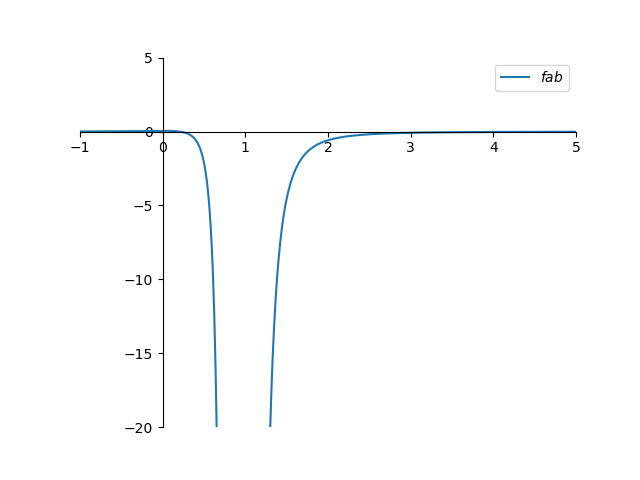

In [ ]:
fnp = sp.lambdify(x,fab)
fig, ax = plt.subplots()
X = np.linspace(-5,10,1001)

ax.plot(X,fnp(X), label=r'$fab$')
ax.axis((-1,5,-20,5))
ax.fill_between()
ax.spines[['left', 'bottom']].set_position('zero')
ax.spines[['top', 'right']].set_visible(False)
ax.legend()
